<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Assignment/ESAA_OB_0509_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#필요한 라이브러리 호출

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#데이터 호출

data = pd.read_csv('car_evaluation.csv')
data.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

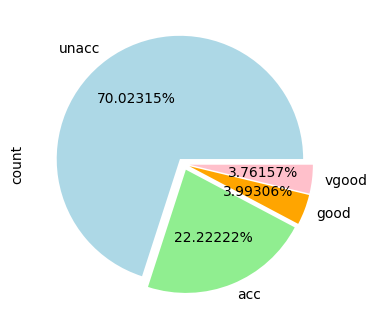

In [2]:
#예제 데이터셋 분포

fig_size = plt.rcParams['figure.figsize']
fig_size[0] = 5
fig_size[1] = 4
plt.rcParams['figure.figsize'] = fig_size
data.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

대부분의 자통차는 허용 불가능한 상태에 있고 20%만 허용 가능한 수준 (불균형 데이터)

딥러닝은 통계 알고리즘을 기반으로 함 -> 범주형 변수를 숫자(텐서)로 변환해야 함

In [3]:
#데이터를 범주형 타입으로 변환

categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety'] #데이터셋 칼럼 목록

for category in categorical_columns:
  data[category] = data[category].astype('category') #범주형으로 변환

price = data['price'].cat.codes.values #범주형 데이터->넘파이배열->텐서
maint = data['maint'].cat.codes.values
doors = data['doors'].cat.codes.values
persons = data['persons'].cat.codes.values
lug_capacity = data['lug_capacity'].cat.codes.values
safety = data['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1) #np.stack은 넘파이 객체를 합치는 함수
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

**참고**

np.stack vs np.concatenate
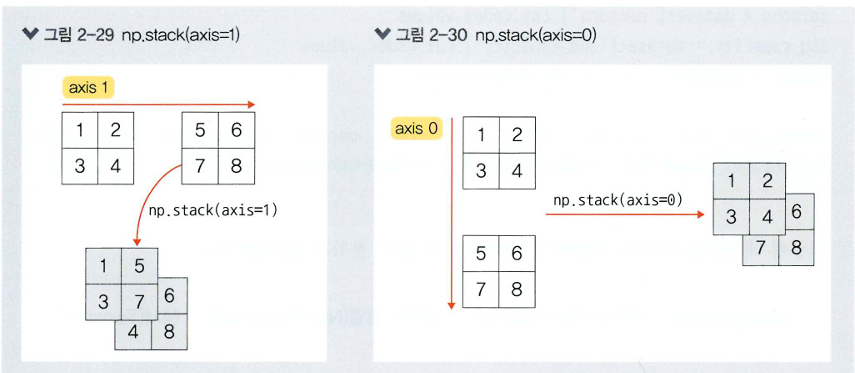


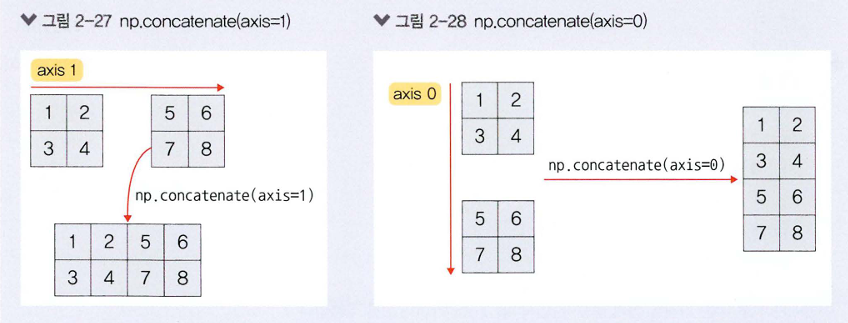

In [4]:
#배열을 텐서로 변환

categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [5]:
#레이블로 사용할 칼럼을 텐서로 변환

outputs = pd.get_dummies(data.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [6]:
#범주형 칼럼을 N차원으로 변환

categorical_column_sizes = [len(data[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [7]:
#데이터셋 분리

total_records = 1728
test_records = int(total_records * 0.2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [8]:
#데이터셋 분리 확인

print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [9]:
#모델 네트워크 생성

class Model(nn.Module): #클래스로 구현되는 모델은 nn.Module을 상속받음
  def __init__(self, embedding_size, output_size, layers, p=0.4): #__init__()는 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용됨
    super().__init__() #super().__init__()는 부모 클래스에 접근할 때 사용
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    for i in layers: #모델의 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계층을 all_layers 목록에 추가
      all_layers.append(nn.Linear(input_size, i)) #선형 계층
      all_layers.append(nn.ReLU(inplace=True)) #활성화 함수
      all_layers.append(nn.BatchNorm1d(i)) #배치 정규화
      all_layers.append(nn.Dropout(p)) #과적합 방지
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers)

  def forward(self, x_categorical): #forward()함수는 학습 데이터를 입력받아서 연산을 진행함
    embeddings = []
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:, i]))
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

In [10]:
#Model 클래스의 객체 생성

model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model) #모델에 대한 구조(네트워크)를 보여줌

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [11]:
#모델 파라미터의 정의

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
#cpu/gpu 사용 지정

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [13]:
#모델 학습

epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)
for i in range(epochs):
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.60415220
epoch:  26 loss: 1.42394054
epoch:  51 loss: 1.32550764
epoch:  76 loss: 1.22140634
epoch: 101 loss: 1.08150017
epoch: 126 loss: 0.95720583
epoch: 151 loss: 0.83509773
epoch: 176 loss: 0.76457852
epoch: 201 loss: 0.71236539
epoch: 226 loss: 0.66740036
epoch: 251 loss: 0.64893538
epoch: 276 loss: 0.62216145
epoch: 301 loss: 0.61889982
epoch: 326 loss: 0.61393851
epoch: 351 loss: 0.59846276
epoch: 376 loss: 0.58508044
epoch: 401 loss: 0.58522266
epoch: 426 loss: 0.58586484
epoch: 451 loss: 0.58126748
epoch: 476 loss: 0.58373481
epoch: 500 loss: 0.5835240483


In [15]:
#테스트 데이터셋으로 모델 예측

test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val.to(device=device), test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.55973482


In [16]:
#모델의 예측 확인

print(y_val[:5])

tensor([[ 3.3648,  1.9420, -4.2973, -4.2585],
        [ 2.8881,  1.6728, -3.2818, -3.2102],
        [ 2.5656,  1.6646, -3.1878, -2.8817],
        [ 2.1084,  1.2689, -3.1515, -3.0408],
        [ 2.0006,  1.0818, -2.8365, -2.8976]])


In [17]:
#가장 큰 값을 갖는 인덱스 확인

y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [20]:
#테스트 데이터셋을 이용한 정확도 확인

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs.cpu(), y_val))
print(classification_report(test_outputs.cpu(), y_val))
print(accuracy_score(test_outputs.cpu(), y_val))

[[258   1]
 [ 83   3]]
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       259
           1       0.75      0.03      0.07        86

    accuracy                           0.76       345
   macro avg       0.75      0.52      0.46       345
weighted avg       0.75      0.76      0.66       345

0.7565217391304347
